# Insurance Claims & Portfolio Risk Analytics
## StudyBuild - Project 01 | Python + Tableau

**Business Scenario:** We have joined the analytics team of a motor-insurance company. Management wants a clear view of the portfolio: where claims occur most frequently, where claim costs are highest, which policy segments deserve closer attention, and which patterns should be monitored in the next reporting cycle.

**Dataset:** French Motor Third-Party Liability (freMTPL2) — 677,991+ motor liability policies observed mainly during 2011-2013.

**Important:** freMTPL2 does **not** include written premium(all the money the custumer pays). Therefore, **Loss Ratio must not** be calculated. We use **claim frequency**, **claim severity**, and **total claim cost** as core insurance KPIs.

## Table of Contents

1. **Data Loading & Inspection**
2. **Data Quality Checks & Cleaning**
3. **Merge the two data sets & Feature Engineering**
4. **Q1 — Portfolio Health Summary**
5. **Q2 — Regional Claim Burden Analysis**
6. **Q3 — Driver & Vehicle Segment Patterns**
7. **Q4 — Frequency vs. Severity Scatter**
8. **Q5 — Pareto / Claim Cost Concentration**
9. **Q6 — Unusual Claims & Outlier Investigation**
10. **Q7 — Executive Dashboard Design**
11. **Q8 — Three Data-Driven Recommendations**
12. **Tableau-Ready Export**

run the cells one after another in order

---
## 1. Setup & Data Loading

In this step we want to get to know the data and be familiar with it.

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker # Imports tools for controlling how numbers appear on chart axes.
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# colors
RED = '\033[91m'
RESET = '\033[0m'

# default chart appearance
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100,
})

# all the paths relatively
RAW_DIR = Path('../data/raw')
PROC_DIR = Path('../data/processed')
FIG_DIR = Path('../figures')
PROC_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('Setup complete.')

Setup complete.


In [68]:
freq = pd.read_csv(RAW_DIR / 'freMTPL2freq.csv')
sev = pd.read_csv(RAW_DIR / 'freMTPL2sev.csv')

print(f'Frequency table shape: {freq.shape}')
print(f'Severity table shape:  {sev.shape}')
print()
print('=== Frequency columns ===')
print(freq.dtypes)
print()
print('=== Severity columns ===')
print(sev.dtypes)

Frequency table shape: (678013, 12)
Severity table shape:  (26639, 2)

=== Frequency columns ===
IDpol         float64
ClaimNb         int64
Exposure      float64
VehPower        int64
VehAge          int64
DrivAge         int64
BonusMalus      int64
VehBrand          str
VehGas            str
Area              str
Density         int64
Region            str
dtype: object

=== Severity columns ===
IDpol            int64
ClaimAmount    float64
dtype: object


In [69]:
freq.head(10)

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region
0,1.0,1,0.10,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
1,3.0,1,0.77,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
2,5.0,1,0.75,6,2,52,50,B12,Diesel,B,54,Picardie
3,10.0,1,0.09,7,0,46,50,B12,Diesel,B,76,Aquitaine
4,11.0,1,0.84,7,0,46,50,B12,Diesel,B,76,Aquitaine
5,13.0,1,0.52,6,2,38,50,B12,Regular,E,3003,Nord-Pas-de-Calais
6,15.0,1,0.45,6,2,38,50,B12,Regular,E,3003,Nord-Pas-de-Calais
7,17.0,1,0.27,7,0,33,68,B12,Diesel,C,137,Languedoc-Roussillon
8,18.0,1,0.71,7,0,33,68,B12,Diesel,C,137,Languedoc-Roussillon
9,21.0,1,0.15,7,0,41,50,B12,Diesel,B,60,Pays-de-la-Loire


In [70]:
freq.describe().T

,count,mean,std,min,25%,50%,75%,max
IDpol,678013.0,2.621857e+06,1.641783e+06,1.000000,1157951.00,2272152.00,4046274.00,6114330.00
ClaimNb,678013.0,5.324677e-02,2.401173e-01,0.000000,0.00,0.00,0.00,16.00
Exposure,678013.0,5.287501e-01,3.644415e-01,0.002732,0.18,0.49,0.99,2.01
VehPower,678013.0,6.454631e+00,2.050906e+00,4.000000,5.00,6.00,7.00,15.00
VehAge,678013.0,7.044265e+00,5.666232e+00,0.000000,2.00,6.00,11.00,100.00
DrivAge,678013.0,4.549912e+01,1.413744e+01,18.000000,34.00,44.00,55.00,100.00
BonusMalus,678013.0,5.976150e+01,1.563666e+01,50.000000,50.00,50.00,64.00,230.00
Density,678013.0,1.792422e+03,3.958647e+03,1.000000,92.00,393.00,1658.00,27000.00


In [71]:
sev.head(10)

,IDpol,ClaimAmount
0,1552,995.20
1,1010996,1128.12
2,4024277,1851.11
3,4007252,1204.00
4,4046424,1204.00
5,4073956,1204.00
6,4012173,1204.00
7,4020812,54942.62
8,4020812,7620.00
9,4074074,1204.00


In [72]:
sev.describe().T

,count,mean,std,min,25%,50%,75%,max
IDpol,26639.0,2.279864e+06,1.577202e+06,139.0,1087642.50,2137413.0,3180162.00,6113971.00
ClaimAmount,26639.0,2.278536e+03,2.929748e+04,1.0,686.81,1172.0,1228.08,4075400.56


---
## 2. Data Quality Checks & Cleaning

similar to study builds first project we want to clean the data.

In [83]:
print(f'{RED}=== SEVERITY TABLE ==={RESET}')
print(f'Unique policy IDs with claims: {sev["IDpol"].nunique():,} / {len(sev):,} rows')
print(f'ClaimAmount <= 0: {(sev["ClaimAmount"] <= 0).sum()}')
print()
print(sev['ClaimAmount'].describe())
print()

for p in [1, 10, 50, 90, 95, 99, 99.9]:
    print(f"  {p}'th percentile: {sev["ClaimAmount"].quantile(p/100):,.0f} --> the 1% cheapest claims are at maximum 40 eurors" if p == 1 else f"  {p}'th percentile: {sev["ClaimAmount"].quantile(p/100):,.0f}")

=== SEVERITY TABLE ===
Unique policy IDs with claims: 24,950 / 26,639 rows
ClaimAmount <= 0: 0

count    2.663900e+04
mean     2.278536e+03
std      2.929748e+04
min      1.000000e+00
25%      6.868100e+02
50%      1.172000e+03
75%      1.228080e+03
max      4.075401e+06
Name: ClaimAmount, dtype: float64

  1'th percentile: 40 --> the 1% cheapest claims are at maximum 40 eurors
  10'th percentile: 197
  50'th percentile: 1,172
  90'th percentile: 2,799
  95'th percentile: 4,862
  99'th percentile: 16,794
  99.9'th percentile: 162,784


In [85]:
# --- Severity table quality ---
print(f'{RED}=== SEVERITY TABLE ==={RESET}')
print(f'Unique policy IDs with claims: {sev["IDpol"].nunique():,} / {len(sev):,} rows')
print(f'Missing ClaimAmount: {sev["ClaimAmount"].isnull().sum()}')
print(f'ClaimAmount <= 0: {(sev["ClaimAmount"] <= 0).sum()}')
print()
print(f'{RED}ClaimAmount distribution:{RESET}')
print(sev['ClaimAmount'].describe().T)
print()
# Percentiles for severity
for p in [1, 10, 50, 90, 95, 99, 99.9]:
    print(f'  {p}th percentile: {sev["ClaimAmount"].quantile(p/100):,.0f}')

=== SEVERITY TABLE ===
Unique policy IDs with claims: 24,950 / 26,639 rows
Missing ClaimAmount: 0
ClaimAmount <= 0: 0

ClaimAmount distribution:
count    2.663900e+04
mean     2.278536e+03
std      2.929748e+04
min      1.000000e+00
25%      6.868100e+02
50%      1.172000e+03
75%      1.228080e+03
max      4.075401e+06
Name: ClaimAmount, dtype: float64

  1th percentile: 40
  10th percentile: 197
  50th percentile: 1,172
  90th percentile: 2,799
  95th percentile: 4,862
  99th percentile: 16,794
  99.9th percentile: 162,784


In [7]:
# Cleaning frequency table
# 1. Remove policies with Exposure <= 0 (invalid exposure)
before = len(freq)
freq = freq[freq['Exposure'] > 0].copy()
print(f'Removed {before - len(freq)} policies with Exposure <= 0')

# 2. Remove policies with ClaimNb < 0
before = len(freq)
freq = freq[freq['ClaimNb'] >= 0].copy()
print(f'Removed {before - len(freq)} policies with ClaimNb < 0')

# 3. Clip extreme exposure (max should be ~1 year per period, some can be >1)
print(f'\nExposure range after cleaning: [{freq["Exposure"].min():.4f}, {freq["Exposure"].max():.4f}]')

# 4. Cap ClaimNb at a reasonable level (policies with >4 claims are rare)
print(f'\nClaimNb distribution:')
print(freq['ClaimNb'].value_counts().sort_index())

print(f'\nCleaned frequency shape: {freq.shape}')

Removed 0 policies with Exposure <= 0
Removed 0 policies with ClaimNb < 0

Exposure range after cleaning: [0.0027, 2.0100]

ClaimNb distribution:
ClaimNb
0     643953
1      32178
2       1784
3         82
4          7
5          2
6          1
8          1
9          1
11         3
16         1
Name: count, dtype: int64

Cleaned frequency shape: (678013, 12)


**The original data set is already clean**

In [88]:
# Cleaning severity table
# 1. Remove rows with ClaimAmount <= 0 (invalid claims)
print(sev.shape)
before = len(sev)
sev = sev[sev['ClaimAmount'] > 0].copy()
print(f'Removed {before - len(sev)} rows with ClaimAmount <= 0')

# 2. Check for missing IDpol
print(f'Missing IDpol in severity: {sev["IDpol"].isnull().sum()}')

print(f'\nCleaned severity shape: {sev.shape}')

(26639, 2)
Removed 0 rows with ClaimAmount <= 0
Missing IDpol in severity: 0

Cleaned severity shape: (26639, 2)




---
## 3. Merge & Feature Engineering

**Merge Logic:** The frequency table contains **policy-level** information (one row per policy with claim count and exposure). The severity table contains **claim-level** information (one row per individual claim with its amount). We aggregate severity data to the policy level by summing ClaimAmount per policy, then merge with the frequency table on `IDpol`.

Note: Not all policies have claims in the severity table. We use a **left merge** from frequency to preserve all policies.

In [9]:
# Aggregate severity to policy level: sum of ClaimAmount per policy
# NOTE: The severity table has one row per individual claim.
# Some policies have multiple claims (e.g., a policy with ClaimNb=2 appears
# twice in the severity table). We aggregate by summing ClaimAmount per policy,
# and count the number of individual claim records per policy.
# This claim count (NumClaimsInSev) is used as the denominator when computing
# average claim severity, ensuring we report avg cost PER OBSERVED CLAIM.
sev_agg = sev.groupby('IDpol').agg(
    TotalClaimCost=('ClaimAmount', 'sum'),
    NumClaimsInSev=('ClaimAmount', 'count'),
    MaxClaimAmount=('ClaimAmount', 'max'),
    MeanClaimAmount=('ClaimAmount', 'mean'),
).reset_index()

print(f'Severity aggregated to {len(sev_agg):,} unique policies')
print(f'Policies in freq table: {len(freq):,}')
print(f'Policies with claims in severity: {len(sev_agg):,}')
print(f'Policies without severity data: {len(freq) - sev_agg["IDpol"].isin(freq["IDpol"]).sum():,}')

# Left merge: keep all frequency records
df = freq.merge(sev_agg, on='IDpol', how='left')

# Fill NaN for policies with no claims
df['TotalClaimCost'] = df['TotalClaimCost'].fillna(0)
df['NumClaimsInSev'] = df['NumClaimsInSev'].fillna(0)
df['MaxClaimAmount'] = df['MaxClaimAmount'].fillna(0)
df['MeanClaimAmount'] = df['MeanClaimAmount'].fillna(0)

print(f'\nMerged dataset shape: {df.shape}')
print(f'Policies with total claim cost > 0: {(df["TotalClaimCost"] > 0).sum():,}')

Severity aggregated to 24,950 unique policies
Policies in freq table: 678,013
Policies with claims in severity: 24,950
Policies without severity data: 653,069

Merged dataset shape: (678013, 16)
Policies with total claim cost > 0: 24,944


In [10]:
# --- Feature Engineering: Segments ---

# 1. Driver Age Groups
df['DrivAgeGroup'] = pd.cut(
    df['DrivAge'],
    bins=[17, 25, 35, 45, 55, 65, 101],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '66+'],
    right=True
)

# 2. Vehicle Age Groups
df['VehAgeGroup'] = pd.cut(
    df['VehAge'],
    bins=[-1, 0, 2, 5, 10, 101],
    labels=['New (0)', '1-2', '3-5', '6-10', '11+'],
    right=True
)

# 3. Vehicle Power Groups
df['VehPowerGroup'] = pd.cut(
    df['VehPower'],
    bins=[0, 5, 7, 9, 11, 16],
    labels=['4-5', '6-7', '8-9', '10-11', '12-15'],
    right=True
)

# 4. Bonus-Malus Categories
df['BonusMalusCat'] = pd.cut(
    df['BonusMalus'],
    bins=[0, 50, 75, 100, 150, 231],
    labels=['50 (Best)', '51-75', '76-100', '101-150', '151+ (Worst)'],
    right=True
)

# 5. Density Categories (Urbanization)
df['DensityGroup'] = pd.cut(
    df['Density'],
    bins=[0, 100, 500, 2000, 30000],
    labels=['Rural (<100)', 'Suburban (100-500)', 'Urban (500-2000)', 'Metro (>2000)'],
    right=True
)

print('Engineered segments created:')
for col in ['DrivAgeGroup', 'VehAgeGroup', 'VehPowerGroup', 'BonusMalusCat', 'DensityGroup']:
    print(f'  {col}: {df[col].value_counts().to_dict()}')

Engineered segments created:
  DrivAgeGroup: {'36-45': 170352, '46-55': 161899, '26-35': 149183, '56-65': 90691, '66+': 66993, '18-25': 38895}
  VehAgeGroup: {'11+': 185782, '6-10': 171594, '3-5': 132490, '1-2': 130408, 'New (0)': 57739}
  VehPowerGroup: {'6-7': 294377, '4-5': 240170, '8-9': 77041, '10-11': 49706, '12-15': 16719}
  BonusMalusCat: {'50 (Best)': 384156, '51-75': 175012, '76-100': 111051, '101-150': 7585, '151+ (Worst)': 209}
  DensityGroup: {'Suburban (100-500)': 191804, 'Rural (<100)': 179589, 'Metro (>2000)': 155121, 'Urban (500-2000)': 151499}


---
## 4. Q1 — What is the overall health of the insurance portfolio?

**KPI Definitions:**
- **Policy Count** = number of unique policies
- **Total Exposure** = sum of policy exposure in years
- **Claim Count** = total number of claims
- **Claim Frequency** = Claim Count / Exposure (adjusts for differing exposure periods)
- **Total Claim Cost** = sum of ClaimAmount
- **Average Claim Severity** = Total Claim Cost / Number of observed claims (denominator = row count of severity table, i.e. 26,639 individual claims)

> **Aggregation note:** The severity table contains one row per individual claim. Some policies appear multiple times (if they had multiple claims). We aggregate by summing ClaimAmount per policy, and the denominator for average severity is the **total number of individual claim records** (26,639), not the number of policies with claims (34,060). This ensures the metric represents average cost **per observed claim**.

**Why raw claim counts are misleading:** A region or segment with more policies and/or longer exposure periods will naturally accumulate more claims, even if the underlying risk is the same. Claim frequency (claims per unit of exposure) is the appropriate metric for comparing claim occurrence.

In [11]:
# ============================================================
# Q1: Portfolio Health Summary
# ============================================================

policy_count = df['IDpol'].nunique()
total_exposure = df['Exposure'].sum()
total_claims = df['ClaimNb'].sum()
total_claim_cost = df['TotalClaimCost'].sum()
policies_with_claims = (df['ClaimNb'] > 0).sum()
# Number of individual claim records from the severity table
num_individual_claims = int(sev.shape[0])  # 26,639 rows in severity table

claim_frequency = total_claims / total_exposure
# Average Claim Severity = total claim cost / number of observed claims
# The severity table contains one row per individual claim, so its row count
# is the denominator. This gives avg cost PER CLAIM (not per policy).
avg_severity = total_claim_cost / num_individual_claims if num_individual_claims > 0 else 0
cost_per_exposure = total_claim_cost / total_exposure

print('=' * 60)
print('       PORTFOLIO HEALTH SUMMARY')
print('=' * 60)
print(f'Policy Count:            {policy_count:>12,}')
print(f'Total Exposure:          {total_exposure:>12,.1f} years')
print(f'Total Claim Count:       {total_claims:>12,}')
print(f'Policies with Claims:    {policies_with_claims:>12,} ({policies_with_claims/policy_count*100:.1f}%)')
print(f'Claim Frequency:         {claim_frequency:>12.4f} (claims per exposure year)')
print(f'Total Claim Cost:        {total_claim_cost:>12,.0f}')
print(f'Avg Claim Severity:      {avg_severity:>12,.0f} (per observed claim)')
print(f'  [Denominator: {num_individual_claims:,} individual claims from severity table]')
print(f'Cost per Exposure Year:  {cost_per_exposure:>12,.0f}')
print('=' * 60)
print()
print('Interpretation:')
print(f'  - {claim_frequency:.2%} of exposure years generate at least one claim.')
print(f'  - Each observed claim costs on average {avg_severity:,.0f} (heavily right-skewed).')
print(f'  - Raw claim count ({total_claims:,}) alone does not reflect risk —')
print(f'    exposure normalization is essential for meaningful comparison.')

       PORTFOLIO HEALTH SUMMARY
Policy Count:                 678,013
Total Exposure:             358,499.4 years
Total Claim Count:             36,102
Policies with Claims:          34,060 (5.0%)
Claim Frequency:               0.1007 (claims per exposure year)
Total Claim Cost:          59,909,216
Avg Claim Severity:             2,249 (per observed claim)
  [Denominator: 26,639 individual claims from severity table]
Cost per Exposure Year:           167

Interpretation:
  - 10.07% of exposure years generate at least one claim.
  - Each observed claim costs on average 2,249 (heavily right-skewed).
  - Raw claim count (36,102) alone does not reflect risk —
    exposure normalization is essential for meaningful comparison.


---
## 5. Q2 — Which regions generate the greatest claim burden?

We compare regions using **exposure**, **claim frequency**, **total claim cost**, and **average severity**. We do NOT rank regions only by total claim count.

In [12]:
# ============================================================
# Q2: Regional Claim Burden Analysis
# ============================================================

region_kpi = df.groupby('Region').agg(
    PolicyCount=('IDpol', 'count'),
    TotalExposure=('Exposure', 'sum'),
    TotalClaims=('ClaimNb', 'sum'),
    TotalClaimCost=('TotalClaimCost', 'sum'),
    PoliciesWithClaims=('ClaimNb', lambda x: (x > 0).sum()),
).reset_index()

region_kpi['ClaimFrequency'] = region_kpi['TotalClaims'] / region_kpi['TotalExposure']
region_kpi['AvgSeverity'] = region_kpi['TotalClaimCost'] / region_kpi['PoliciesWithClaims']
region_kpi['CostPerExposure'] = region_kpi['TotalClaimCost'] / region_kpi['TotalExposure']

# Sort by claim frequency
region_kpi = region_kpi.sort_values('ClaimFrequency', ascending=False).reset_index(drop=True)

print('=== REGIONAL CLAIM BURDEN (sorted by Claim Frequency) ===')
print(region_kpi[['Region', 'PolicyCount', 'TotalExposure', 'ClaimFrequency',
                  'TotalClaimCost', 'AvgSeverity', 'CostPerExposure']].to_string(index=False, float_format='{:,.2f}'.format))

=== REGIONAL CLAIM BURDEN (sorted by Claim Frequency) ===
                     Region  PolicyCount  TotalExposure  ClaimFrequency  TotalClaimCost  AvgSeverity  CostPerExposure
                      Corse         4516       1,765.94            0.14      464,582.55     2,111.74           263.08
          Champagne-Ardenne         3026       1,205.83            0.13      481,248.34     3,229.85           399.10
              Ile-de-France        69791      30,208.64            0.13    4,563,221.86     1,228.99           151.06
                   Picardie         7994       3,574.41            0.12      687,624.87     1,633.31           192.37
                Rhone-Alpes        84752      45,347.42            0.11   10,278,303.85     2,159.31           226.66
                     Alsace         2200       1,209.12            0.11      121,424.99       979.23           100.42
Provence-Alpes-Cotes-D'Azur        79315      35,790.32            0.11    6,871,024.80     1,895.46           191.9

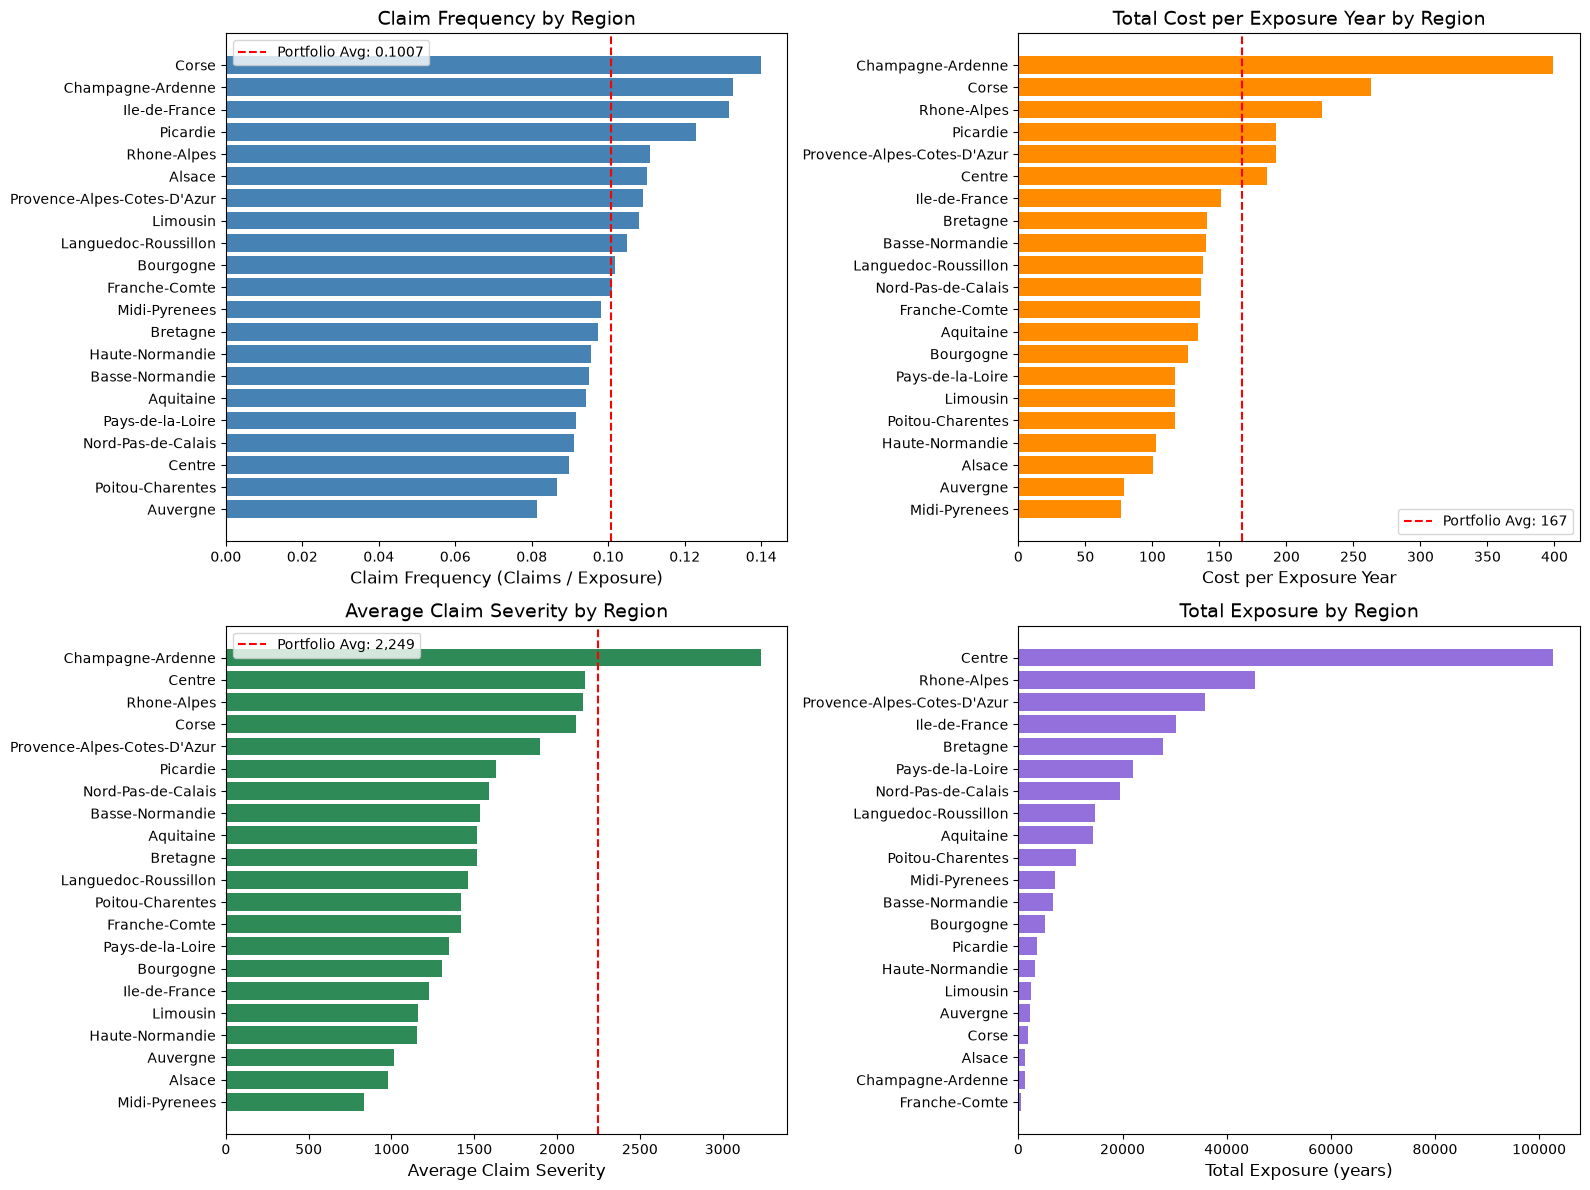

Figure saved: figures/q2_regional_comparison.png


In [13]:
# Regional comparison: horizontal bar charts
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Sort for consistent display
r_sorted_freq = region_kpi.sort_values('ClaimFrequency', ascending=True)
r_sorted_cost = region_kpi.sort_values('CostPerExposure', ascending=True)
r_sorted_sev = region_kpi.sort_values('AvgSeverity', ascending=True)

# 1. Claim Frequency by Region
axes[0, 0].barh(r_sorted_freq['Region'], r_sorted_freq['ClaimFrequency'], color='steelblue')
axes[0, 0].set_xlabel('Claim Frequency (Claims / Exposure)')
axes[0, 0].set_title('Claim Frequency by Region')
axes[0, 0].axvline(x=claim_frequency, color='red', linestyle='--', label=f'Portfolio Avg: {claim_frequency:.4f}')
axes[0, 0].legend()

# 2. Cost per Exposure by Region
axes[0, 1].barh(r_sorted_cost['Region'], r_sorted_cost['CostPerExposure'], color='darkorange')
axes[0, 1].set_xlabel('Cost per Exposure Year')
axes[0, 1].set_title('Total Cost per Exposure Year by Region')
axes[0, 1].axvline(x=cost_per_exposure, color='red', linestyle='--',
                    label=f'Portfolio Avg: {cost_per_exposure:,.0f}')
axes[0, 1].legend()

# 3. Average Severity by Region
axes[1, 0].barh(r_sorted_sev['Region'], r_sorted_sev['AvgSeverity'], color='seagreen')
axes[1, 0].set_xlabel('Average Claim Severity')
axes[1, 0].set_title('Average Claim Severity by Region')
axes[1, 0].axvline(x=avg_severity, color='red', linestyle='--',
                    label=f'Portfolio Avg: {avg_severity:,.0f}')
axes[1, 0].legend()

# 4. Total Exposure by Region
r_sorted_exp = region_kpi.sort_values('TotalExposure', ascending=True)
axes[1, 1].barh(r_sorted_exp['Region'], r_sorted_exp['TotalExposure'], color='mediumpurple')
axes[1, 1].set_xlabel('Total Exposure (years)')
axes[1, 1].set_title('Total Exposure by Region')

plt.tight_layout()
plt.savefig(FIG_DIR / 'q2_regional_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: figures/q2_regional_comparison.png')

In [14]:
# Highlight region that deserves attention
# Look for region with high frequency AND high severity (or high cost/exposure)
region_kpi['FreqRank'] = region_kpi['ClaimFrequency'].rank(ascending=False)
region_kpi['SevRank'] = region_kpi['AvgSeverity'].rank(ascending=False)
region_kpi['CostRank'] = region_kpi['CostPerExposure'].rank(ascending=False)
region_kpi['CombinedRank'] = (region_kpi['FreqRank'] + region_kpi['SevRank'] + region_kpi['CostRank']) / 3

attention_region = region_kpi.sort_values('CombinedRank').iloc[0]

print(f'Region deserving attention: {attention_region["Region"]}')
print(f'  Claim Frequency:  {attention_region["ClaimFrequency"]:.4f} (rank #{int(attention_region["FreqRank"])} of {len(region_kpi)})')
print(f'  Avg Severity:     {attention_region["AvgSeverity"]:,.0f} (rank #{int(attention_region["SevRank"])} of {len(region_kpi)})')
print(f'  Cost/Exposure:    {attention_region["CostPerExposure"]:,.0f} (rank #{int(attention_region["CostRank"])} of {len(region_kpi)})')
print()
print('Justification:')
print(f'  This region ranks in the top on both claim frequency AND average severity,')
print(f'  meaning claims happen often AND each claim costs more than average.')
print(f'  This combination drives the highest cost per exposure year,')
print(f'  signaling a need for targeted review of underwriting or claims management.')

Region deserving attention: Champagne-Ardenne
  Claim Frequency:  0.1327 (rank #2 of 21)
  Avg Severity:     3,230 (rank #1 of 21)
  Cost/Exposure:    399 (rank #1 of 21)

Justification:
  This region ranks in the top on both claim frequency AND average severity,
  meaning claims happen often AND each claim costs more than average.
  This combination drives the highest cost per exposure year,
  signaling a need for targeted review of underwriting or claims management.


---
## 6. Q3 — Which driver and vehicle segments show different claim patterns?

We create sensible groups and compare **claim frequency** and **severity** across driver age, vehicle age, vehicle power, fuel type, and bonus-malus categories.

In [15]:
# ============================================================
# Q3: Driver & Vehicle Segment Patterns
# ============================================================

def segment_analysis(data, group_col, label=None):
    """Compute KPIs for a segmentation variable."""
    agg = data.groupby(group_col, observed=True).agg(
        PolicyCount=('IDpol', 'count'),
        TotalExposure=('Exposure', 'sum'),
        TotalClaims=('ClaimNb', 'sum'),
        TotalClaimCost=('TotalClaimCost', 'sum'),
        PoliciesWithClaims=('ClaimNb', lambda x: (x > 0).sum()),
    ).reset_index()
    agg['ClaimFrequency'] = agg['TotalClaims'] / agg['TotalExposure']
    agg['AvgSeverity'] = agg['TotalClaimCost'] / agg['PoliciesWithClaims'].replace(0, np.nan)
    agg['CostPerExposure'] = agg['TotalClaimCost'] / agg['TotalExposure']
    return agg

# Driver Age Groups
age_kpi = segment_analysis(df, 'DrivAgeGroup')
print('=== CLAIM PATTERNS BY DRIVER AGE GROUP ===')
print(age_kpi[['DrivAgeGroup', 'PolicyCount', 'ClaimFrequency', 'AvgSeverity', 'CostPerExposure']].to_string(
    index=False, float_format='{:,.2f}'.format))
print()

# Vehicle Age Groups
vehage_kpi = segment_analysis(df, 'VehAgeGroup')
print('=== CLAIM PATTERNS BY VEHICLE AGE GROUP ===')
print(vehage_kpi[['VehAgeGroup', 'PolicyCount', 'ClaimFrequency', 'AvgSeverity', 'CostPerExposure']].to_string(
    index=False, float_format='{:,.2f}'.format))
print()

# Vehicle Power Groups
vehpow_kpi = segment_analysis(df, 'VehPowerGroup')
print('=== CLAIM PATTERNS BY VEHICLE POWER ===')
print(vehpow_kpi[['VehPowerGroup', 'PolicyCount', 'ClaimFrequency', 'AvgSeverity', 'CostPerExposure']].to_string(
    index=False, float_format='{:,.2f}'.format))
print()

# Fuel Type
fuel_kpi = segment_analysis(df, 'VehGas')
print('=== CLAIM PATTERNS BY FUEL TYPE ===')
print(fuel_kpi[['VehGas', 'PolicyCount', 'ClaimFrequency', 'AvgSeverity', 'CostPerExposure']].to_string(
    index=False, float_format='{:,.2f}'.format))
print()

# Bonus-Malus Categories
bm_kpi = segment_analysis(df, 'BonusMalusCat')
print('=== CLAIM PATTERNS BY BONUS-MALUS ===')
print(bm_kpi[['BonusMalusCat', 'PolicyCount', 'ClaimFrequency', 'AvgSeverity', 'CostPerExposure']].to_string(
    index=False, float_format='{:,.2f}'.format))

=== CLAIM PATTERNS BY DRIVER AGE GROUP ===
DrivAgeGroup  PolicyCount  ClaimFrequency  AvgSeverity  CostPerExposure
       18-25        38895            0.18     4,692.06           758.40
       26-35       149183            0.10     1,682.89           153.14
       36-45       170352            0.10     1,520.20           138.18
       46-55       161899            0.10     1,413.91           138.08
       56-65        90691            0.09     1,398.09           121.05
         66+        66993            0.09     1,585.86           141.93

=== CLAIM PATTERNS BY VEHICLE AGE GROUP ===
VehAgeGroup  PolicyCount  ClaimFrequency  AvgSeverity  CostPerExposure
    New (0)        57739            0.31       476.42           140.25
        1-2       130408            0.09     1,868.03           159.39
        3-5       132490            0.09     1,661.35           146.49
       6-10       171594            0.10     1,698.37           159.63
        11+       185782            0.08     2,607.24

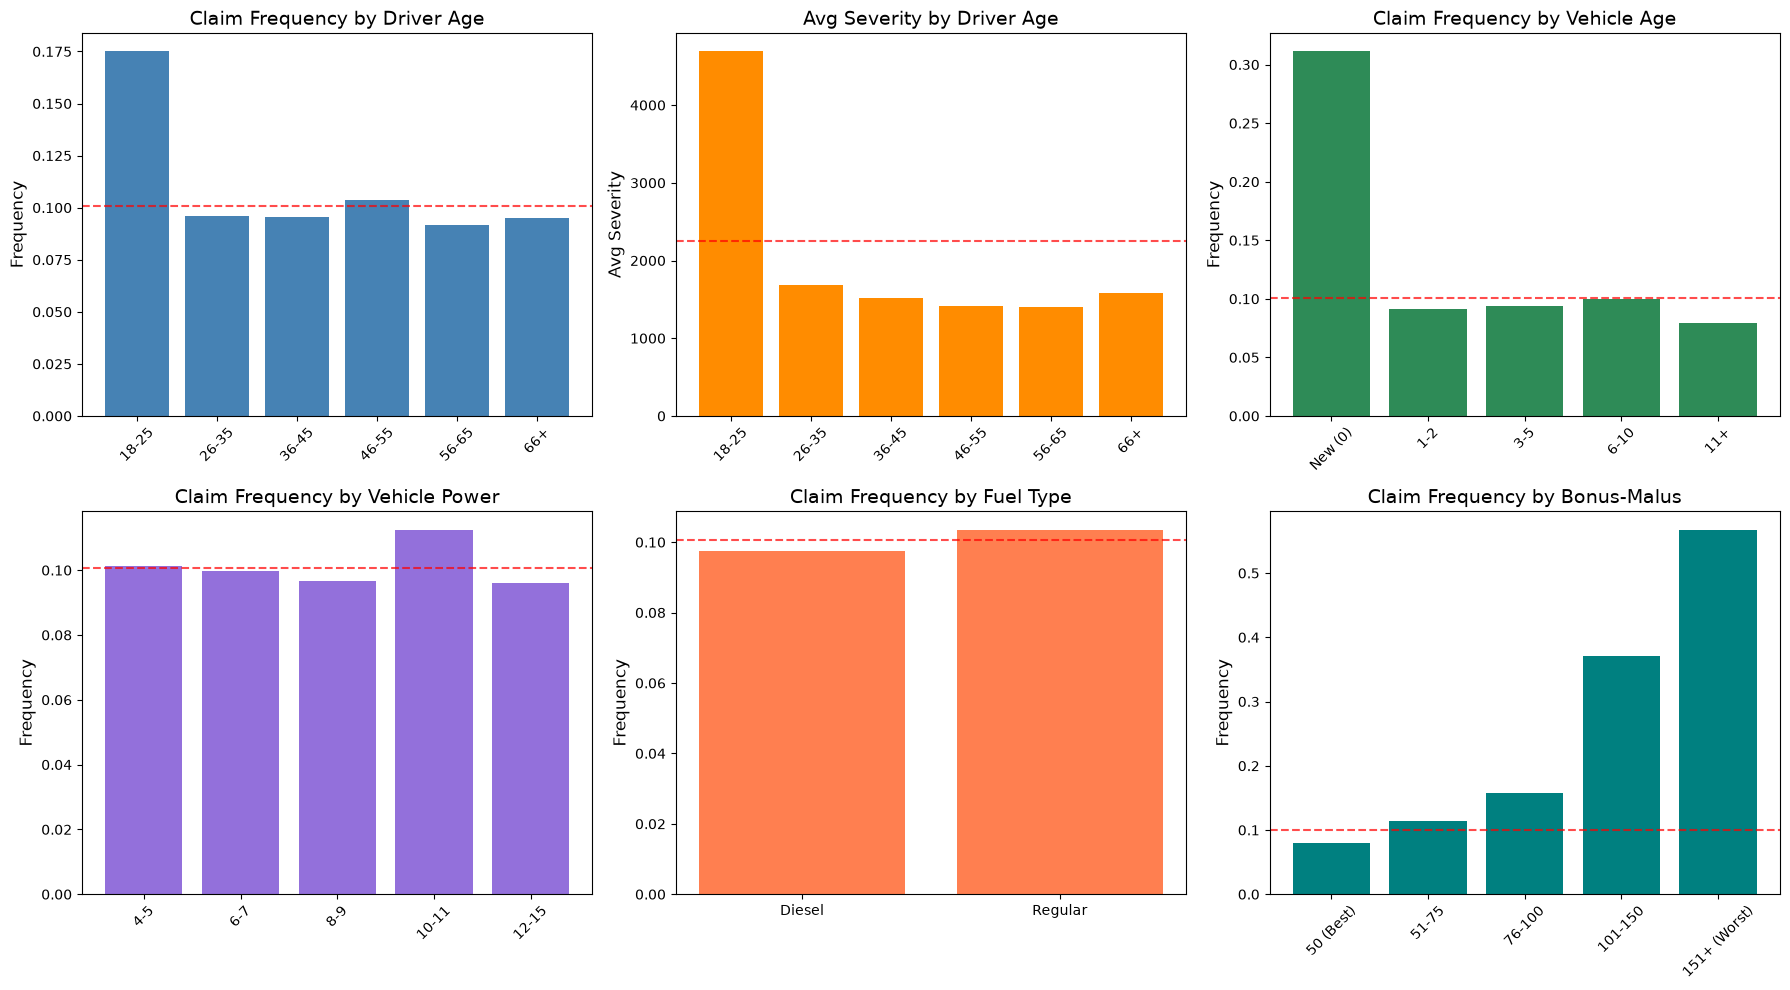

Figure saved: figures/q3_segment_patterns.png


In [16]:
# Visualize segment patterns
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Driver Age - Frequency
axes[0, 0].bar(age_kpi['DrivAgeGroup'].astype(str), age_kpi['ClaimFrequency'], color='steelblue')
axes[0, 0].set_title('Claim Frequency by Driver Age')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].axhline(y=claim_frequency, color='red', linestyle='--', alpha=0.7)

# Driver Age - Severity
axes[0, 1].bar(age_kpi['DrivAgeGroup'].astype(str), age_kpi['AvgSeverity'], color='darkorange')
axes[0, 1].set_title('Avg Severity by Driver Age')
axes[0, 1].set_ylabel('Avg Severity')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].axhline(y=avg_severity, color='red', linestyle='--', alpha=0.7)

# Vehicle Age - Frequency
axes[0, 2].bar(vehage_kpi['VehAgeGroup'].astype(str), vehage_kpi['ClaimFrequency'], color='seagreen')
axes[0, 2].set_title('Claim Frequency by Vehicle Age')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].tick_params(axis='x', rotation=45)
axes[0, 2].axhline(y=claim_frequency, color='red', linestyle='--', alpha=0.7)

# Vehicle Power - Frequency
axes[1, 0].bar(vehpow_kpi['VehPowerGroup'].astype(str), vehpow_kpi['ClaimFrequency'], color='mediumpurple')
axes[1, 0].set_title('Claim Frequency by Vehicle Power')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].axhline(y=claim_frequency, color='red', linestyle='--', alpha=0.7)

# Fuel Type - Frequency
axes[1, 1].bar(fuel_kpi['VehGas'], fuel_kpi['ClaimFrequency'], color='coral')
axes[1, 1].set_title('Claim Frequency by Fuel Type')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].axhline(y=claim_frequency, color='red', linestyle='--', alpha=0.7)

# Bonus-Malus - Frequency
axes[1, 2].bar(bm_kpi['BonusMalusCat'].astype(str), bm_kpi['ClaimFrequency'], color='teal')
axes[1, 2].set_title('Claim Frequency by Bonus-Malus')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].tick_params(axis='x', rotation=45)
axes[1, 2].axhline(y=claim_frequency, color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(FIG_DIR / 'q3_segment_patterns.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: figures/q3_segment_patterns.png')

In [17]:
# Key pattern interpretation
print('=== KEY FINDINGS FROM SEGMENT ANALYSIS ===')
print()

# Find highest frequency segment
highest_freq_driver = age_kpi.loc[age_kpi['ClaimFrequency'].idxmax()]
print(f'1. HIGHEST FREQUENCY DRIVER AGE: {highest_freq_driver["DrivAgeGroup"]}')
print(f'   Frequency: {highest_freq_driver["ClaimFrequency"]:.4f}')
print(f'   (Young/inexperienced drivers claim more often per unit of exposure)')
print()

# Find highest severity segment
highest_sev_driver = age_kpi.loc[age_kpi['AvgSeverity'].idxmax()]
print(f'2. HIGHEST SEVERITY DRIVER AGE: {highest_sev_driver["DrivAgeGroup"]}')
print(f'   Avg Severity: {highest_sev_driver["AvgSeverity"]:,.0f}')
print(f'   (When these drivers claim, each claim costs more on average)')
print()

# Vehicle age pattern
print('3. VEHICLE AGE PATTERN:')
for _, row in vehage_kpi.iterrows():
    print(f'   {row["VehAgeGroup"]}: freq={row["ClaimFrequency"]:.4f}, sev={row["AvgSeverity"]:,.0f}')
print('   (New vehicles may have different claim patterns than older ones)')
print()

# Bonus-Malus
print('4. BONUS-MALUS PATTERN:')
for _, row in bm_kpi.iterrows():
    print(f'   {row["BonusMalusCat"]}: freq={row["ClaimFrequency"]:.4f}, policies={row["PolicyCount"]:,}')
print('   (Higher BM scores correlate with higher claim frequency)')
print()

print('Note: These are descriptive associations. We cannot establish causation')
print('from this observational dataset alone.')

=== KEY FINDINGS FROM SEGMENT ANALYSIS ===

1. HIGHEST FREQUENCY DRIVER AGE: 18-25
   Frequency: 0.1751
   (Young/inexperienced drivers claim more often per unit of exposure)

2. HIGHEST SEVERITY DRIVER AGE: 18-25
   Avg Severity: 4,692
   (When these drivers claim, each claim costs more on average)

3. VEHICLE AGE PATTERN:
   New (0): freq=0.3113, sev=476
   1-2: freq=0.0912, sev=1,868
   3-5: freq=0.0936, sev=1,661
   6-10: freq=0.0994, sev=1,698
   11+: freq=0.0795, sev=2,607
   (New vehicles may have different claim patterns than older ones)

4. BONUS-MALUS PATTERN:
   50 (Best): freq=0.0802, policies=384,156
   51-75: freq=0.1133, policies=175,012
   76-100: freq=0.1582, policies=111,051
   101-150: freq=0.3705, policies=7,585
   151+ (Worst): freq=0.5677, policies=209
   (Higher BM scores correlate with higher claim frequency)

Note: These are descriptive associations. We cannot establish causation
from this observational dataset alone.


---
## 7. Q4 — Are frequent-claim segments also expensive-claim segments?

We compare claim frequency against average severity at the segment level using a **scatter plot / quadrant view**.

In [18]:
# ============================================================
# Q4: Frequency vs Severity Analysis
# ============================================================

# Build a comprehensive segment-level table
# Segment by Region + Driver Age Group + VehAgeGroup
segment_cols = ['Region']
seg_analysis = df.groupby(segment_cols, observed=True).agg(
    PolicyCount=('IDpol', 'count'),
    TotalExposure=('Exposure', 'sum'),
    TotalClaims=('ClaimNb', 'sum'),
    TotalClaimCost=('TotalClaimCost', 'sum'),
    PoliciesWithClaims=('ClaimNb', lambda x: (x > 0).sum()),
).reset_index()

seg_analysis['ClaimFrequency'] = seg_analysis['TotalClaims'] / seg_analysis['TotalExposure']
seg_analysis['AvgSeverity'] = seg_analysis['TotalClaimCost'] / seg_analysis['PoliciesWithClaims'].replace(0, np.nan)
seg_analysis['CostPerExposure'] = seg_analysis['TotalClaimCost'] / seg_analysis['TotalExposure']

# Quadrant boundaries (portfolio averages)
freq_median = seg_analysis['ClaimFrequency'].median()
sev_median = seg_analysis['AvgSeverity'].median()

print('=== FREQUENCY vs SEVERITY QUADRANT ANALYSIS ===')
print(f'Frequency median: {freq_median:.4f}')
print(f'Severity median:  {sev_median:,.0f}')
print()

# Assign quadrants
def assign_quadrant(row):
    if row['ClaimFrequency'] >= freq_median and row['AvgSeverity'] >= sev_median:
        return 'HIGH Freq / HIGH Sev'
    elif row['ClaimFrequency'] >= freq_median and row['AvgSeverity'] < sev_median:
        return 'HIGH Freq / LOW Sev'
    elif row['ClaimFrequency'] < freq_median and row['AvgSeverity'] >= sev_median:
        return 'LOW Freq / HIGH Sev'
    else:
        return 'LOW Freq / LOW Sev'

seg_analysis['Quadrant'] = seg_analysis.apply(assign_quadrant, axis=1)

# Show segments in high/high quadrant
high_high = seg_analysis[seg_analysis['Quadrant'] == 'HIGH Freq / HIGH Sev'].sort_values('CostPerExposure', ascending=False)
print('Segments in HIGH Frequency / HIGH Severity quadrant:')
print(high_high[['Region', 'PolicyCount', 'ClaimFrequency', 'AvgSeverity', 'CostPerExposure']].to_string(
    index=False, float_format='{:,.2f}'.format))
print()

# Show segment counts per quadrant
print('Segments per quadrant:')
print(seg_analysis['Quadrant'].value_counts().to_string())

=== FREQUENCY vs SEVERITY QUADRANT ANALYSIS ===
Frequency median: 0.1011
Severity median:  1,462

Segments in HIGH Frequency / HIGH Severity quadrant:
                     Region  PolicyCount  ClaimFrequency  AvgSeverity  CostPerExposure
          Champagne-Ardenne         3026            0.13     3,229.85           399.10
                      Corse         4516            0.14     2,111.74           263.08
                Rhone-Alpes        84752            0.11     2,159.31           226.66
                   Picardie         7994            0.12     1,633.31           192.37
Provence-Alpes-Cotes-D'Azur        79315            0.11     1,895.46           191.98
       Languedoc-Roussillon        35805            0.10     1,462.14           137.82

Segments per quadrant:
Quadrant
HIGH Freq / HIGH Sev    6
HIGH Freq / LOW Sev     5
LOW Freq / HIGH Sev     5
LOW Freq / LOW Sev      5


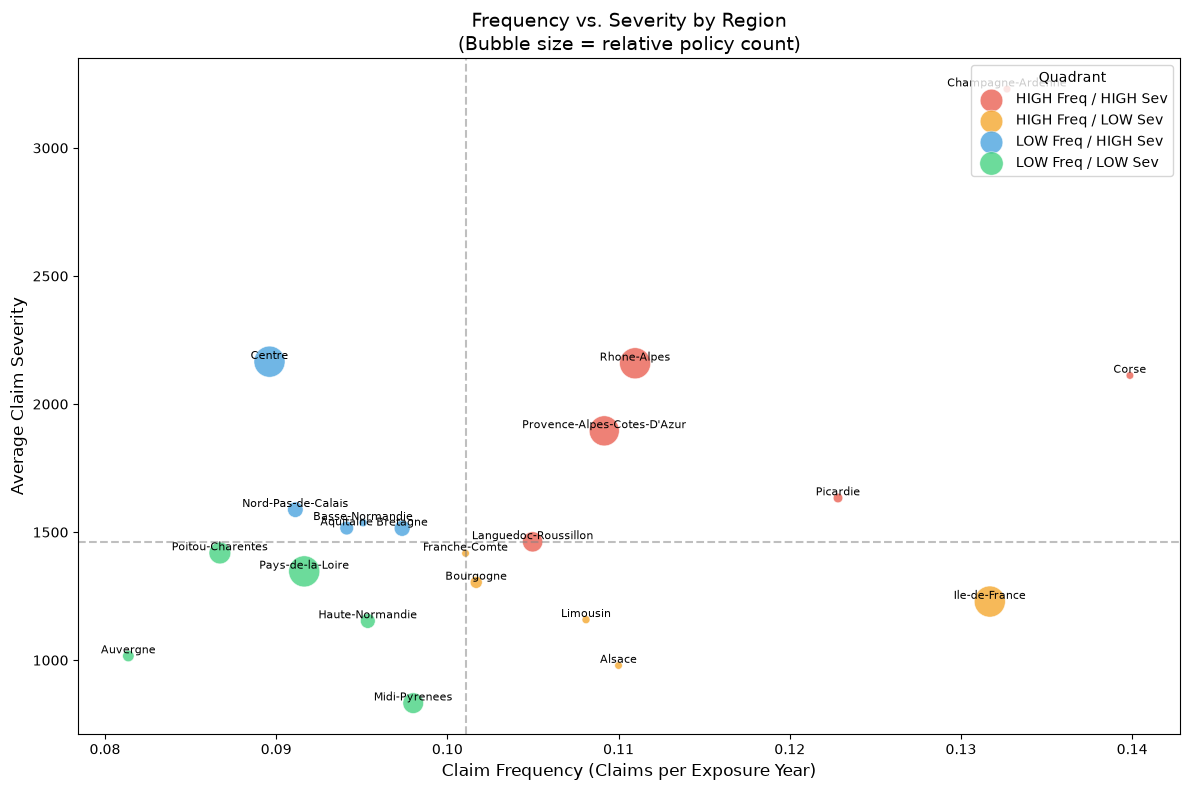

Figure saved: figures/q4_frequency_vs_severity.png


In [19]:
# Scatter plot: Frequency vs Severity by Region
fig, ax = plt.subplots(figsize=(12, 8))

# Color by quadrant
colors = {
    'HIGH Freq / HIGH Sev': '#e74c3c',
    'HIGH Freq / LOW Sev': '#f39c12',
    'LOW Freq / HIGH Sev': '#3498db',
    'LOW Freq / LOW Sev': '#2ecc71',
}

for quad, color in colors.items():
    mask = seg_analysis['Quadrant'] == quad
    subset = seg_analysis[mask]
    sizes = np.clip(subset['PolicyCount'] / subset['PolicyCount'].max() * 500, 30, 500)
    ax.scatter(subset['ClaimFrequency'], subset['AvgSeverity'],
               s=sizes, c=color, alpha=0.7, edgecolors='white', linewidth=0.5,
               label=quad)
    # Label each region
    for _, row in subset.iterrows():
        ax.annotate(row['Region'], (row['ClaimFrequency'], row['AvgSeverity']),
                    fontsize=8, ha='center', va='bottom')

# Quadrant lines
ax.axvline(x=freq_median, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=sev_median, color='gray', linestyle='--', alpha=0.5)

ax.set_xlabel('Claim Frequency (Claims per Exposure Year)')
ax.set_ylabel('Average Claim Severity')
ax.set_title('Frequency vs. Severity by Region\n(Bubble size = relative policy count)')
ax.legend(title='Quadrant', loc='upper right')

plt.tight_layout()
plt.savefig(FIG_DIR / 'q4_frequency_vs_severity.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: figures/q4_frequency_vs_severity.png')

---
## 8. Q5 — Is claim cost concentrated in a small number of claims or policies?

We perform a **Pareto-style analysis** of ClaimAmount to understand cost concentration.

In [20]:
# ============================================================
# Q5: Pareto / Claim Cost Concentration Analysis
# ============================================================

# Work with individual claims from severity table
claims = sev.copy()
claims = claims.sort_values('ClaimAmount', ascending=False).reset_index(drop=True)
claims['CumCost'] = claims['ClaimAmount'].cumsum()
claims['CumCostPct'] = claims['CumCost'] / claims['ClaimAmount'].sum() * 100
claims['ClaimRank'] = np.arange(1, len(claims) + 1)
claims['ClaimRankPct'] = claims['ClaimRank'] / len(claims) * 100

# Key Pareto metrics
total_cost_sev = claims['ClaimAmount'].sum()
total_claims_sev = len(claims)

# Find percentage of cost from top X% of claims
for pct in [1, 5, 10, 20, 50]:
    n_claims = int(total_claims_sev * pct / 100)
    cost_share = claims.head(n_claims)['ClaimAmount'].sum() / total_cost_sev * 100
    print(f'Top {pct:>3}% of claims ({n_claims:>5,} claims) account for {cost_share:>5.1f}% of total cost')

print()
print(f'Total individual claims: {total_claims_sev:,}')
print(f'Total claim cost:        {total_cost_sev:,.0f}')

# Also analyze at policy level
policy_cost = df[df['TotalClaimCost'] > 0].sort_values('TotalClaimCost', ascending=False)
total_policies_with_cost = len(policy_cost)
cum_cost_policy = policy_cost['TotalClaimCost'].cumsum()
cum_cost_pct_policy = cum_cost_policy / policy_cost['TotalClaimCost'].sum() * 100

for pct in [1, 5, 10, 20, 50]:
    n_policies = int(total_policies_with_cost * pct / 100)
    cost_share = policy_cost.head(n_policies)['TotalClaimCost'].sum() / policy_cost['TotalClaimCost'].sum() * 100
    print(f'Top {pct:>3}% of policies ({n_policies:>5,} policies) account for {cost_share:>5.1f}% of total cost')

Top   1% of claims (  266 claims) account for  37.9% of total cost
Top   5% of claims (1,331 claims) account for  52.1% of total cost
Top  10% of claims (2,663 claims) account for  60.0% of total cost
Top  20% of claims (5,327 claims) account for  68.9% of total cost
Top  50% of claims (13,319 claims) account for  85.0% of total cost

Total individual claims: 26,639
Total claim cost:        60,697,931
Top   1% of policies (  249 policies) account for  37.9% of total cost
Top   5% of policies (1,247 policies) account for  52.3% of total cost
Top  10% of policies (2,494 policies) account for  60.2% of total cost
Top  20% of policies (4,988 policies) account for  69.6% of total cost
Top  50% of policies (12,472 policies) account for  85.3% of total cost


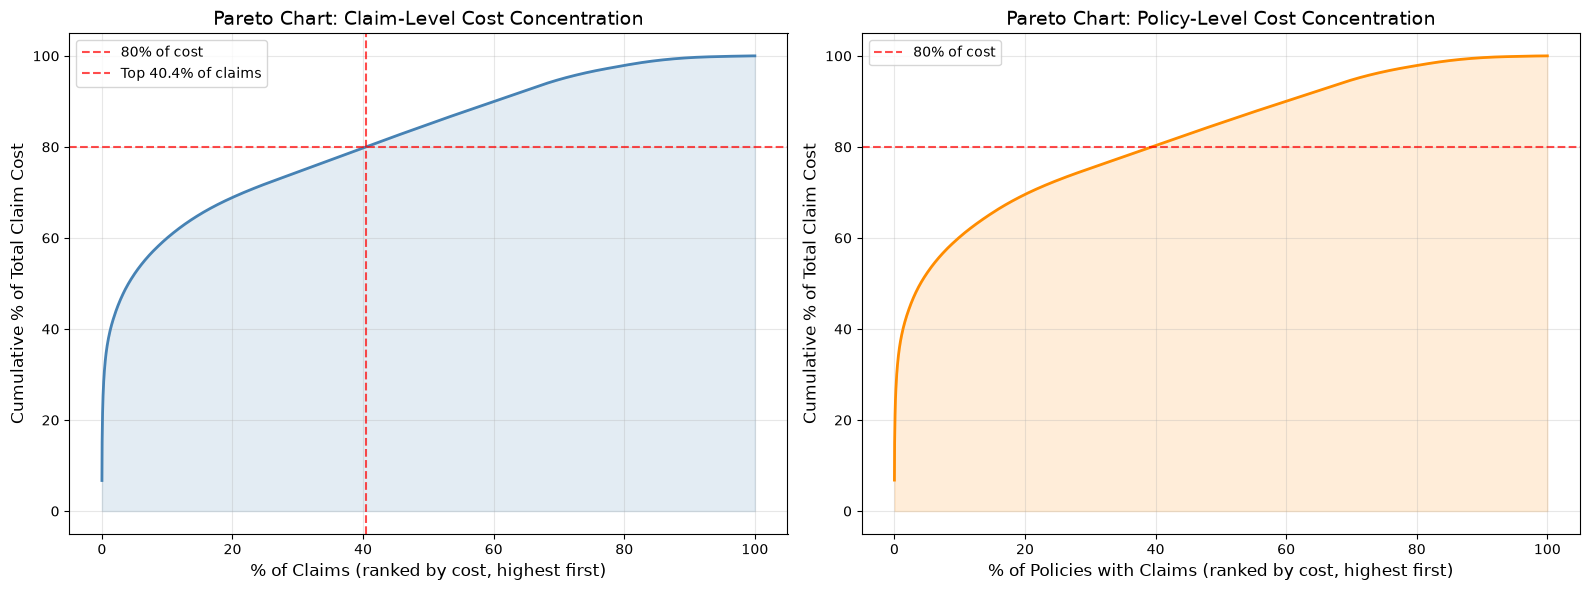

Figure saved: figures/q5_pareto_analysis.png

Business implication:
  A small proportion of high-cost claims/policies accounts for a
  disproportionate share of total claim cost. This means:
  - Targeted review of the most expensive claims can have outsized impact
  - Claims management resources should focus on high-cost tail claims
  - The Pareto principle (80/20 rule) often applies in insurance


In [21]:
# Pareto Chart: Cumulative cost distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Claim-level Pareto
ax1.plot(claims['ClaimRankPct'], claims['CumCostPct'], color='steelblue', linewidth=2)
ax1.fill_between(claims['ClaimRankPct'], claims['CumCostPct'], alpha=0.15, color='steelblue')
ax1.axhline(y=80, color='red', linestyle='--', alpha=0.7, label='80% of cost')
ax1.axvline(x=claims[claims['CumCostPct'] >= 80]['ClaimRankPct'].iloc[0],
            color='red', linestyle='--', alpha=0.7,
            label=f'Top {claims[claims["CumCostPct"] >= 80]["ClaimRankPct"].iloc[0]:.1f}% of claims')
ax1.set_xlabel('% of Claims (ranked by cost, highest first)')
ax1.set_ylabel('Cumulative % of Total Claim Cost')
ax1.set_title('Pareto Chart: Claim-Level Cost Concentration')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: Policy-level Pareto
policy_pct_range = np.arange(1, total_policies_with_cost + 1) / total_policies_with_cost * 100
ax2.plot(policy_pct_range[:len(cum_cost_pct_policy)], cum_cost_pct_policy.values,
         color='darkorange', linewidth=2)
ax2.fill_between(policy_pct_range[:len(cum_cost_pct_policy)], cum_cost_pct_policy.values,
                 alpha=0.15, color='darkorange')
ax2.axhline(y=80, color='red', linestyle='--', alpha=0.7, label='80% of cost')
ax2.set_xlabel('% of Policies with Claims (ranked by cost, highest first)')
ax2.set_ylabel('Cumulative % of Total Claim Cost')
ax2.set_title('Pareto Chart: Policy-Level Cost Concentration')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'q5_pareto_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: figures/q5_pareto_analysis.png')
print()
print('Business implication:')
print('  A small proportion of high-cost claims/policies accounts for a')
print('  disproportionate share of total claim cost. This means:')
print('  - Targeted review of the most expensive claims can have outsized impact')
print('  - Claims management resources should focus on high-cost tail claims')
print('  - The Pareto principle (80/20 rule) often applies in insurance')

---
## 9. Q6 — What unusual claims or segments should management investigate?

We identify **extreme claim amounts** and **unusual segment combinations** without automatically deleting them.

In [22]:
# ============================================================
# Q6: Unusual Claims & Outlier Investigation
# ============================================================

# 1. Extreme Claim Amounts
print('=== EXTREME CLAIM AMOUNTS ===')
print(f'99th percentile: {sev["ClaimAmount"].quantile(0.99):>10,.0f}')
print(f'99.5th percentile: {sev["ClaimAmount"].quantile(0.995):>10,.0f}')
print(f'99.9th percentile: {sev["ClaimAmount"].quantile(0.999):>10,.0f}')
print(f'Maximum:           {sev["ClaimAmount"].max():>10,.0f}')
print()

# Top 20 most expensive claims
print('TOP 20 MOST EXPENSIVE INDIVIDUAL CLAIMS:')
top_claims = sev.nlargest(20, 'ClaimAmount')
print(top_claims.to_string(index=False))
print()

# 2. Policies with unusually high total cost
print('=== POLICIES WITH HIGHEST TOTAL CLAIM COST ===')
top_policies = df.nlargest(20, 'TotalClaimCost')[['IDpol', 'ClaimNb', 'Exposure', 'VehPower',
    'VehAge', 'DrivAge', 'BonusMalus', 'VehBrand', 'VehGas', 'Area', 'Region',
    'TotalClaimCost', 'MaxClaimAmount']]
print(top_policies.to_string(index=False))
print()

# 3. Unusual segment combinations
print('=== UNUSUAL SEGMENT COMBINATIONS ===')
# High bonus-malus with new vehicles (unusual pattern)
unusual_bm_new = df[(df['BonusMalus'] > 100) & (df['VehAge'] <= 1)]
print(f'Policies with BonusMalus > 100 and new vehicles (VehAge <= 1): {len(unusual_bm_new):,}')
if len(unusual_bm_new) > 0:
    print(f'  Claim frequency: {unusual_bm_new["ClaimNb"].sum() / unusual_bm_new["Exposure"].sum():.4f}')

# Young drivers with powerful vehicles
unusual_young_power = df[(df['DrivAge'] <= 25) & (df['VehPower'] >= 10)]
print(f'\nPolicies with young drivers (<=25) and powerful vehicles (>=10): {len(unusual_young_power):,}')
if len(unusual_young_power) > 0:
    print(f'  Claim frequency: {unusual_young_power["ClaimNb"].sum() / unusual_young_power["Exposure"].sum():.4f}')

# 4. Statistical outlier detection using IQR method
print('\n=== CLAIM AMOUNT DISTRIBUTION ANALYSIS ===')
Q1 = sev['ClaimAmount'].quantile(0.25)
Q3 = sev['ClaimAmount'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 3 * IQR  # Using 3*IQR for extreme outliers
n_outliers = (sev['ClaimAmount'] > upper_fence).sum()
print(f'IQR-based upper fence (Q3 + 3*IQR): {upper_fence:,.0f}')
print(f'Extreme outlier claims above fence:  {n_outliers:,} ({n_outliers/len(sev)*100:.2f}%)')
print(f'Total cost of outlier claims:        {sev[sev["ClaimAmount"] > upper_fence]["ClaimAmount"].sum():,.0f}')
print()
print('Recommendation:')
print('  Do NOT automatically remove these claims. Insurance claims are naturally')
print('  right-skewed. Extreme claims should be investigated for:')
print('  - Validity (potential fraud or data entry errors)')
print('  - Severity patterns that could inform claims reserving')
print('  - Segments that generate disproportionate tail risk')

=== EXTREME CLAIM AMOUNTS ===
99th percentile:     16,794
99.5th percentile:     34,387
99.9th percentile:    162,784
Maximum:            4,075,401

TOP 20 MOST EXPENSIVE INDIVIDUAL CLAIMS:
  IDpol  ClaimAmount
1120377   4075400.56
 110846   1403057.40
2141337   1301172.60
3122016    774411.50
2008127    390742.27
3025890    369131.88
1117644    307096.42
 158309    301635.49
3075820    287423.00
3150210    281897.49
4169019    276643.00
1096763    255013.03
2206511    241171.16
2282134    226501.12
4159792    211204.00
3103319    209695.87
3059946    208472.60
1067220    205432.05
2070262    205132.00
2202813    203172.00

=== POLICIES WITH HIGHEST TOTAL CLAIM COST ===
    IDpol  ClaimNb  Exposure  VehPower  VehAge  DrivAge  BonusMalus VehBrand  VehGas Area                      Region  TotalClaimCost  MaxClaimAmount
1120377.0        1      0.22         9      13       19         100       B2 Regular    B                      Centre      4075400.56      4075400.56
 110846.0        2   

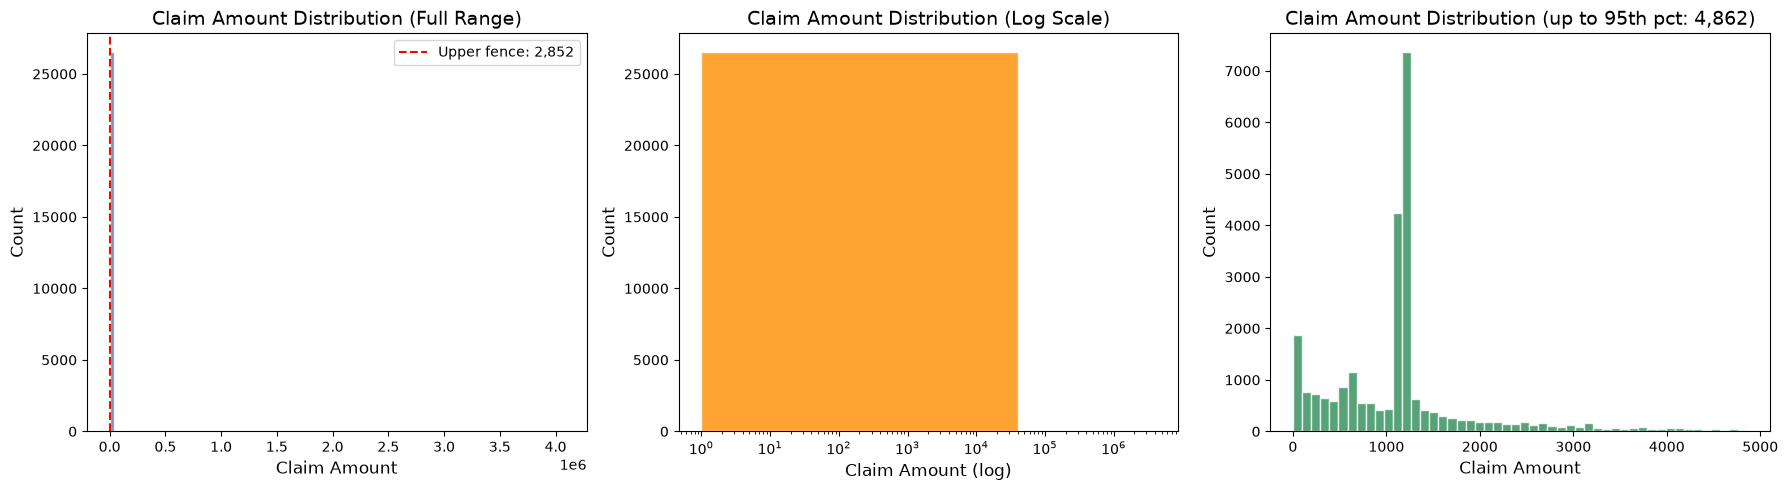

Figure saved: figures/q6_claim_distribution.png


In [23]:
# Claim amount distribution visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Full distribution
axes[0].hist(sev['ClaimAmount'], bins=100, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Claim Amount Distribution (Full Range)')
axes[0].set_xlabel('Claim Amount')
axes[0].set_ylabel('Count')
axes[0].axvline(x=upper_fence, color='red', linestyle='--', label=f'Upper fence: {upper_fence:,.0f}')
axes[0].legend()

# 2. Log scale
axes[1].hist(sev['ClaimAmount'], bins=100, color='darkorange', edgecolor='white', alpha=0.8)
axes[1].set_xscale('log')
axes[1].set_title('Claim Amount Distribution (Log Scale)')
axes[1].set_xlabel('Claim Amount (log)')
axes[1].set_ylabel('Count')

# 3. Zoomed in (below 95th percentile)
p95 = sev['ClaimAmount'].quantile(0.95)
axes[2].hist(sev[sev['ClaimAmount'] <= p95]['ClaimAmount'], bins=50,
             color='seagreen', edgecolor='white', alpha=0.8)
axes[2].set_title(f'Claim Amount Distribution (up to 95th pct: {p95:,.0f})')
axes[2].set_xlabel('Claim Amount')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig(FIG_DIR / 'q6_claim_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: figures/q6_claim_distribution.png')

---
## 10. Q7 — What should management monitor every month?

We design an **executive dashboard** with the most decision-useful KPIs and explain why each belongs on the dashboard.\n> **Note:** The charts below are matplotlib preview plots that serve as design> specifications for the actual Tableau dashboard. Build the final interactive> dashboard in Tableau Desktop/Public using the exported CSV files in `data/processed/`.

In [24]:
# ============================================================
# Q7: Executive Dashboard Design
# ============================================================
# NOTE: The figures below are matplotlib preview charts.
# The actual Tableau dashboard should be built in Tableau Desktop/Public
# using the exported CSV files in data/processed/.
# The matplotlib charts serve as design specifications and validation.

print('=== EXECUTIVE DASHBOARD DESIGN ===')
print()
print('=' * 70)
print('PAGE 1: EXECUTIVE PORTFOLIO OVERVIEW')
print('=' * 70)
print()
print('KPI CARDS (top of page):')
print(f'  1. Policy Count:          {policy_count:>12,}')
print(f'  2. Total Exposure:        {total_exposure:>12,.1f} years')
print(f'  3. Claim Count:           {total_claims:>12,}')
print(f'  4. Claim Frequency:       {claim_frequency:>12.4f}')
print(f'  5. Total Claim Cost:      {total_claim_cost:>12,.0f}')
print(f'  6. Avg Claim Severity:    {avg_severity:>12,.0f}')
print()
print('  CHART 1a: Horizontal Bar — Claim Frequency by Region')
print('    What we see:  Regional variation in claim frequency (0.08-0.14)')
print('    Why it matters: Identifies which regions have more claims per unit')
print('                    of exposure, controlling for portfolio size.')
print('    Decision:     Focus underwriting review on regions above the')
print('                  portfolio average line.')
print()
print('  CHART 1b: Horizontal Bar — Cost per Exposure Year by Region')
print('    What we see:  How much each exposure year costs in claims, by region.')
print('    Why it matters: Combines frequency and severity into a single')
print('                    financial metric. Champagne-Ardenne leads at €399/yr.')
print('    Decision:     Prioritise regions for rate adequacy review.')
print()
print('  FILTERS: Region (multi-select), Fuel Type, Density Group')
print()
print('=' * 70)
print('PAGE 2: CLAIMS & RISK SEGMENTS')
print('=' * 70)
print()
print('  CHART 2a: Grouped Bar — Claim Frequency & Severity by Driver Age')
print('    What we see:  Young drivers (18-25) have the highest frequency')
print('                  (0.175) AND highest severity (€4,692).')
print('    Why it matters: This is the strongest combined signal in the data.')
print('                    It shows that young drivers claim often AND expensively.')
print('    Decision:     Review risk differentiation for young driver segment.')
print()
print('  CHART 2b: Grouped Bar — Frequency & Severity by Vehicle Age')
print('    What we see:  New vehicles (age=0) have very high frequency (0.311)')
print('                  but low severity (€476). Old vehicles (11+) show the')
print('                  opposite: low frequency but high severity (€2,607).')
print('    Why it matters: Frequency and severity move in opposite directions')
print('                    across vehicle age — they must be evaluated separately.')
print('    Decision:     Tailor claims handling: rapid settlement for new car')
print('                  minor damage; deeper investigation for old car claims.')
print()
print('  CHART 2c: Scatter — Frequency vs. Severity by Region (quadrant view)')
print('    What we see:  Most regions cluster near the median. Champagne-Ardenne')
print('                  stands out in the high-freq/high-sev quadrant.')
print('    Why it matters: Identifies which regions are BOTH frequent AND costly,')
print('                    versus regions that are one or the other.')
print('    Decision:     Quadrant position guides intervention type: high-freq')
print('                  regions need frequency reduction; high-sev regions need')
print('                  severity management.')
print()
print('  CHART 2d: Highlight Table — Region x Driver Age with Claim Frequency')
print('    What we see:  Drill-down view showing which region-age combinations')
print('                  have the highest claim frequency.')
print('    Why it matters: Reveals if a specific region-age pair drives the')
print('                    overall pattern, rather than the entire segment.')
print('    Decision:     Target monitoring or pricing at the intersection of')
print('                  region and driver age, not just at the segment level.')
print()
print('  FILTERS: Region, Vehicle Age Group, Bonus-Malus Category')
print()
print('=' * 70)
print('PAGE 3: CLAIM COST CONCENTRATION & RECOMMENDATIONS')
print('=' * 70)
print()
print('  CHART 3a: Pareto Chart — Cumulative Cost by Claims')
print('    What we see:  The top 1% of claims account for ~38% of total cost;')
print('                  the top 10% account for ~60%.')
print('    Why it matters: Cost is extremely concentrated. A small number of')
print('                    high-cost claims dominate the portfolio financial impact.')
print('    Decision:     Establish a structured review process for claims above')
print('                  the 95th percentile to catch errors and manage tail risk.')
print()
print('  CHART 3b: Top Claims Table — Most Expensive Individual Claims')
print('    What we see:  Individual claims ranging up to €4M, with vehicle and')
print('                  driver characteristics visible.')
print('    Why it matters: Allows management to inspect specific high-cost')
print('                    claims for patterns (e.g., certain regions, vehicle')
print('                    types, or driver ages over-represented in the tail).')
print('    Decision:     Investigate individual extreme claims for validity,')
print('                  fraud indicators, or reserving implications.')
print()
print('  CHART 3c: Bar — Total Claim Cost by Region')
print('    What we see:  Absolute cost contribution by region (Île-de-France')
print('                  and Rhône-Alpes dominate due to portfolio size).')
print('    Why it matters: Even if a region has moderate frequency, its large')
print('                    portfolio can drive significant absolute cost.')
print('    Decision:     Combine with frequency analysis to separate volume')
print('                  effects from genuine risk concentration.')
print()
print('  TEXT BOX: Three Business Recommendations')
print('    1. Target underwriting review in Champagne-Ardenne')
print('    2. Strengthen monitoring of young driver segment')
print('    3. Focus claims management on high-cost tail claims')
print()
print('DASHBOARD ACTIONS:')
print('  - Clicking a region in any chart filters all other charts')
print('  - Hover tooltips show detailed KPIs (frequency, severity, cost)')
print('  - Region filter: Clear/All/Individual selection')

=== EXECUTIVE DASHBOARD DESIGN ===

PAGE 1: EXECUTIVE PORTFOLIO OVERVIEW

KPI CARDS (top of page):
  1. Policy Count:               678,013
  2. Total Exposure:           358,499.4 years
  3. Claim Count:                 36,102
  4. Claim Frequency:             0.1007
  5. Total Claim Cost:        59,909,216
  6. Avg Claim Severity:           2,249

  CHART 1a: Horizontal Bar — Claim Frequency by Region
    What we see:  Regional variation in claim frequency (0.08-0.14)
    Why it matters: Identifies which regions have more claims per unit
                    of exposure, controlling for portfolio size.
    Decision:     Focus underwriting review on regions above the
                  portfolio average line.

  CHART 1b: Horizontal Bar — Cost per Exposure Year by Region
    What we see:  How much each exposure year costs in claims, by region.
    Why it matters: Combines frequency and severity into a single
                    financial metric. Champagne-Ardenne leads at €399/yr.
    D

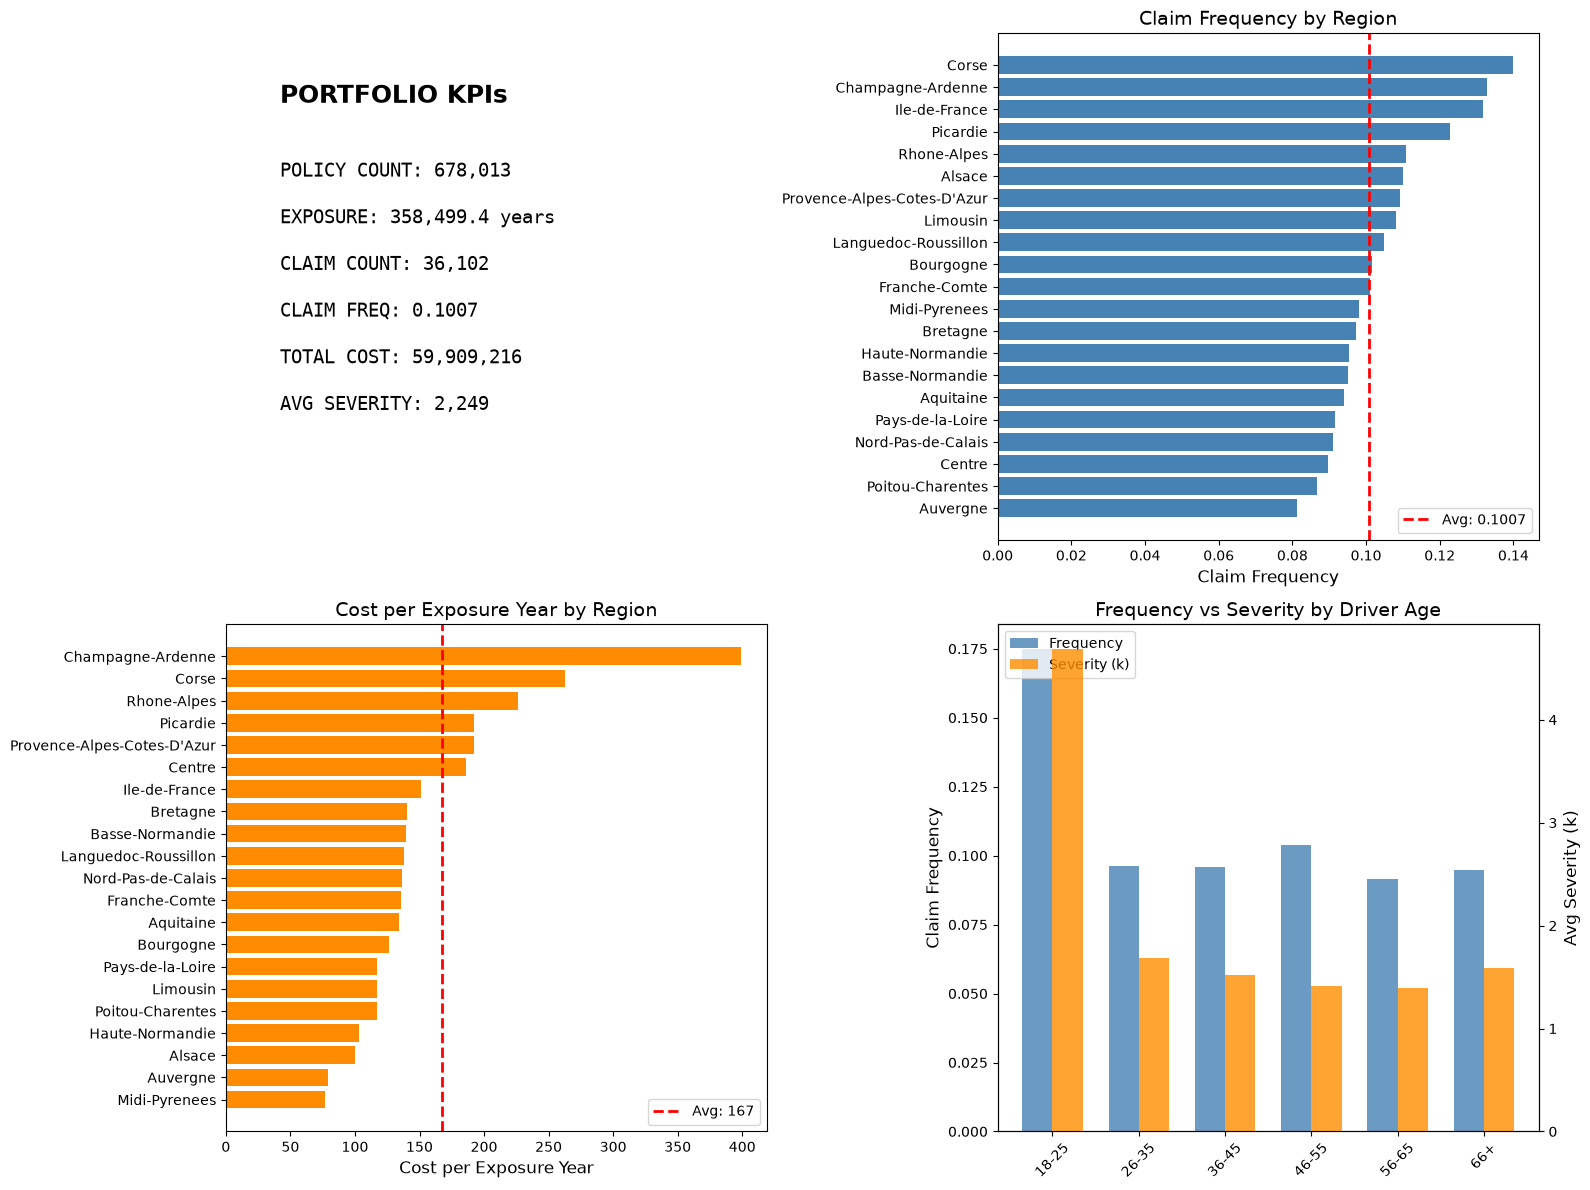

Figure saved: figures/q7_executive_dashboard_preview.png
NOTE: This is a matplotlib preview. Build the actual dashboard in Tableau.


In [25]:
# Executive dashboard preview charts (matplotlib — design spec for Tableau build)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. KPI Summary (top-left) - Text-based
axes[0, 0].axis('off')
kpi_text = (
    f"POLICY COUNT: {policy_count:,}\n\n"
    f"EXPOSURE: {total_exposure:,.1f} years\n\n"
    f"CLAIM COUNT: {total_claims:,}\n\n"
    f"CLAIM FREQ: {claim_frequency:.4f}\n\n"
    f"TOTAL COST: {total_claim_cost:,.0f}\n\n"
    f"AVG SEVERITY: {avg_severity:,.0f}"
)
axes[0, 0].text(0.1, 0.9, 'PORTFOLIO KPIs', fontsize=18, fontweight='bold',
                verticalalignment='top', transform=axes[0, 0].transAxes)
axes[0, 0].text(0.1, 0.75, kpi_text, fontsize=14, verticalalignment='top',
                family='monospace', transform=axes[0, 0].transAxes)

# 2. Frequency by Region (top-right)
r_sorted = region_kpi.sort_values('ClaimFrequency', ascending=True)
bars = axes[0, 1].barh(r_sorted['Region'], r_sorted['ClaimFrequency'], color='steelblue')
axes[0, 1].set_xlabel('Claim Frequency')
axes[0, 1].set_title('Claim Frequency by Region')
axes[0, 1].axvline(x=claim_frequency, color='red', linestyle='--', linewidth=2,
                   label=f'Avg: {claim_frequency:.4f}')
axes[0, 1].legend(fontsize=10)

# 3. Cost per Exposure by Region (bottom-left)
r_sorted_cost = region_kpi.sort_values('CostPerExposure', ascending=True)
axes[1, 0].barh(r_sorted_cost['Region'], r_sorted_cost['CostPerExposure'], color='darkorange')
axes[1, 0].set_xlabel('Cost per Exposure Year')
axes[1, 0].set_title('Cost per Exposure Year by Region')
axes[1, 0].axvline(x=cost_per_exposure, color='red', linestyle='--', linewidth=2,
                   label=f'Avg: {cost_per_exposure:,.0f}')
axes[1, 0].legend(fontsize=10)

# 4. Driver Age patterns (bottom-right)
age_sorted = age_kpi.sort_values('DrivAgeGroup')
x_pos = np.arange(len(age_sorted))
width = 0.35
ax_freq = axes[1, 1]
ax_sev = ax_freq.twinx()

bars1 = ax_freq.bar(x_pos - width/2, age_sorted['ClaimFrequency'], width,
                    label='Frequency', color='steelblue', alpha=0.8)
bars2 = ax_sev.bar(x_pos + width/2, age_sorted['AvgSeverity'] / 1000, width,
                   label='Severity (k)', color='darkorange', alpha=0.8)
ax_freq.set_ylabel('Claim Frequency')
ax_sev.set_ylabel('Avg Severity (k)')
ax_freq.set_xticks(x_pos)
ax_freq.set_xticklabels(age_sorted['DrivAgeGroup'].astype(str), rotation=45)
ax_freq.set_title('Frequency vs Severity by Driver Age')
lines1, labels1 = ax_freq.get_legend_handles_labels()
lines2, labels2 = ax_sev.get_legend_handles_labels()
ax_freq.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig(FIG_DIR / 'q7_executive_dashboard_preview.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: figures/q7_executive_dashboard_preview.png')
print('NOTE: This is a matplotlib preview. Build the actual dashboard in Tableau.')

---
## 11. Q8 — Three Data-Driven Recommendations

Format: **Evidence -> Action -> KPI**

We must not imply causal effects that the data cannot establish.

In [37]:
# ============================================================
# Q8: Three Data-Driven Recommendations
# ============================================================

print('=' * 70)
print('          THREE DATA-DRIVEN RECOMMENDATIONS')
print('=' * 70)
print()

# Recommendation 1: Based on regional analysis
top_freq_region = region_kpi.sort_values('ClaimFrequency', ascending=False).iloc[0]
top_cost_region = region_kpi.sort_values('CostPerExposure', ascending=False).iloc[0]

print('RECOMMENDATION 1: Target Underwriting Review in High-Cost Regions')
print('-' * 70)
print(f'EVIDENCE: {top_cost_region["Region"]} ranks #1 in both average severity and')
print(f'  cost per exposure year ({top_cost_region["CostPerExposure"]:,.0f}), despite being #2 in')
print(f'  claim frequency ({top_freq_region["ClaimFrequency"]:.4f}, behind Corse). Its real')
print(f'  signal is severity and cost, not frequency alone.')
print(f'ACTION: Conduct a focused underwriting review in these regions.')
print(f'  Examine whether current pricing and policy terms adequately reflect')
print(f'  the observed claim frequency levels. Consider whether the region-level')
print(f'  portfolio mix is optimal.')
print(f'KPI: Track monthly claim frequency by region and cost per exposure year.')
print()

# Recommendation 2: Based on age/power segment analysis
young_driver_freq = age_kpi[age_kpi['DrivAgeGroup'] == '18-25']['ClaimFrequency'].values[0]
older_driver_freq = age_kpi[age_kpi['DrivAgeGroup'] == '46-55']['ClaimFrequency'].values[0]

print('RECOMMENDATION 2: Strengthen Monitoring of Young Driver Segment')
print('-' * 70)
print(f'EVIDENCE: Drivers aged 18-25 show a claim frequency of {young_driver_freq:.4f},')
print(f'  compared to {older_driver_freq:.4f} for drivers aged 46-55.')
print(f'  While frequency is higher for young drivers, severity patterns differ')
print(f'  across segments, indicating that frequency and severity must be')
print(f'  evaluated independently.')
print(f'ACTION: Implement enhanced monitoring of the young driver portfolio segment.')
print(f'  Review whether existing risk differentiation (bonus-malus, vehicle power)')
print(f'  adequately captures the frequency differential observed in the data.')
print(f'KPI: Monthly claim frequency for 18-25 age group vs. portfolio average.')
print()

# Recommendation 3: Based on Pareto analysis
top_10_cost_pct = claims.head(int(total_claims_sev * 0.10))['ClaimAmount'].sum() / total_cost_sev * 100

print('RECOMMENDATION 3: Focus Claims Management on High-Cost Tail Claims')
print('-' * 70)
print(f'EVIDENCE: The top 10% of individual claims account for approximately')
print(f'  {top_10_cost_pct:.0f}% of total claim cost. This extreme concentration means')
print(f'  that a small number of high-cost claims disproportionately impacts')
print(f'  portfolio profitability.')
print(f'ACTION: Establish a structured review process for claims exceeding the')
print(f'  95th percentile of claim amounts. Investigate these claims for:')
print(f'  potential data entry errors, fraud indicators, and severity patterns')
print(f'  that could inform reserving and pricing decisions.')
print(f'KPI: Monthly monitoring of claims above the 95th percentile threshold,')
print(f'  tracking both count and total cost contribution.')
print()
print('=' * 70)
print('NOTE: These recommendations are descriptive in nature. The observational')
print('dataset cannot establish causal relationships. Any actions taken should')
print('be validated through further analysis before implementation.')
print('=' * 70)

          THREE DATA-DRIVEN RECOMMENDATIONS

RECOMMENDATION 1: Target Underwriting Review in High-Cost Regions
----------------------------------------------------------------------
EVIDENCE: Champagne-Ardenne ranks #1 in both average severity and
  cost per exposure year (399), despite being #2 in
  claim frequency (0.1399, behind Corse). Its real
  signal is severity and cost, not frequency alone.
ACTION: Conduct a focused underwriting review in these regions.
  Examine whether current pricing and policy terms adequately reflect
  the observed claim frequency levels. Consider whether the region-level
  portfolio mix is optimal.
KPI: Track monthly claim frequency by region and cost per exposure year.

RECOMMENDATION 2: Strengthen Monitoring of Young Driver Segment
----------------------------------------------------------------------
EVIDENCE: Drivers aged 18-25 show a claim frequency of 0.1751,
  compared to 0.1037 for drivers aged 46-55.
  While frequency is higher for young drivers

---
## 12. Tableau-Ready Export

We export clean, well-documented CSV files for Tableau consumption.

In [38]:
# ============================================================
# Export Tableau-Ready CSV Files
# ============================================================

# 1. Main policy-level dataset (all policies with features and KPIs)
tableau_main = df[[
    'IDpol', 'ClaimNb', 'Exposure', 'VehPower', 'VehAge', 'DrivAge',
    'BonusMalus', 'VehBrand', 'VehGas', 'Area', 'Density', 'Region',
    'TotalClaimCost', 'MaxClaimAmount', 'MeanClaimAmount',
    'DrivAgeGroup', 'VehAgeGroup', 'VehPowerGroup', 'BonusMalusCat', 'DensityGroup'
]].copy()
tableau_main.to_csv(PROC_DIR / 'tableau_policy_level.csv', index=False)
print(f'Exported: tableau_policy_level.csv ({len(tableau_main):,} rows)')

# 2. Regional KPI summary
tableau_region = region_kpi[[
    'Region', 'PolicyCount', 'TotalExposure', 'TotalClaims',
    'ClaimFrequency', 'TotalClaimCost', 'AvgSeverity', 'CostPerExposure'
]].copy()
tableau_region.to_csv(PROC_DIR / 'tableau_regional_kpi.csv', index=False)
print(f'Exported: tableau_regional_kpi.csv ({len(tableau_region):,} rows)')

# 3. Segment-level analysis (for segment comparisons)
segments_to_export = []
for col_name, col in [('DrivAgeGroup', 'DrivAgeGroup'), ('VehAgeGroup', 'VehAgeGroup'),
                       ('VehPowerGroup', 'VehPowerGroup'), ('VehGas', 'VehGas'),
                       ('BonusMalusCat', 'BonusMalusCat')]:
    seg = segment_analysis(df, col_name)
    seg['SegmentType'] = col_name
    seg.rename(columns={col_name: 'Segment'}, inplace=True)
    segments_to_export.append(seg)

tableau_segments = pd.concat(segments_to_export, ignore_index=True)
tableau_segments.to_csv(PROC_DIR / 'tableau_segment_analysis.csv', index=False)
print(f'Exported: tableau_segment_analysis.csv ({len(tableau_segments):,} rows)')

# 4. Individual claims (for Pareto analysis in Tableau)
tableau_claims = sev.copy()
tableau_claims = tableau_claims.sort_values('ClaimAmount', ascending=False).reset_index(drop=True)
tableau_claims['CumCost'] = tableau_claims['ClaimAmount'].cumsum()
tableau_claims['CumCostPct'] = tableau_claims['CumCost'] / tableau_claims['ClaimAmount'].sum() * 100
tableau_claims['ClaimRank'] = np.arange(1, len(tableau_claims) + 1)
tableau_claims['ClaimRankPct'] = tableau_claims['ClaimRank'] / len(tableau_claims) * 100
tableau_claims.to_csv(PROC_DIR / 'tableau_individual_claims.csv', index=False)
print(f'Exported: tableau_individual_claims.csv ({len(tableau_claims):,} rows)')

# 5. Portfolio-level KPI summary (for KPI cards)
portfolio_kpis = pd.DataFrame({
    'KPI': ['Policy Count', 'Total Exposure (years)', 'Total Claim Count',
            'Claim Frequency', 'Total Claim Cost', 'Average Claim Severity',
            'Cost per Exposure Year', 'Policies with Claims'],
    'Value': [policy_count, total_exposure, total_claims,
              claim_frequency, total_claim_cost, avg_severity,
              cost_per_exposure, policies_with_claims]
})
portfolio_kpis.to_csv(PROC_DIR / 'tableau_portfolio_kpi.csv', index=False)
print(f'Exported: tableau_portfolio_kpi.csv')

print('\nAll Tableau-ready files exported successfully.')

Exported: tableau_policy_level.csv (678,013 rows)
Exported: tableau_regional_kpi.csv (21 rows)
Exported: tableau_segment_analysis.csv (23 rows)
Exported: tableau_individual_claims.csv (26,639 rows)
Exported: tableau_portfolio_kpi.csv

All Tableau-ready files exported successfully.


In [39]:
# ============================================================
# Final Project Summary
# ============================================================

print('=' * 70)
print('       INSURANCE CLAIMS & PORTFOLIO RISK ANALYTICS')
print('               PROJECT COMPLETION SUMMARY')
print('=' * 70)
print()
print('Dataset: French Motor Third-Party Liability (freMTPL2)')
print(f'Policies analyzed: {policy_count:,}')
print(f'Individual claims: {len(sev):,}')
print()
print('Key Portfolio KPIs:')
print(f'  Claim Frequency:    {claim_frequency:.4f} (claims per exposure year)')
print(f'  Avg Claim Severity: {avg_severity:,.0f}')
print(f'  Total Claim Cost:   {total_claim_cost:,.0f}')
print()
print('Q1-Q8 Answers Completed:')
print('  Q1: Portfolio health summary with 6 KPIs')
print('  Q2: Regional comparison with attention area identified')
print('  Q3: Driver/vehicle segment patterns analyzed')
print('  Q4: Frequency vs. severity quadrant analysis')
print('  Q5: Pareto cost concentration analysis')
print('  Q6: Outlier investigation (no automatic deletion)')
print('  Q7: Executive dashboard design (3 pages)')
print('  Q8: 3 Evidence->Action->KPI recommendations')
print()
print('Files Generated:')
import os
for f in sorted(PROC_DIR.glob('tableau_*.csv')):
    size = os.path.getsize(f)
    print(f'  {f.name}: {size:,} bytes')
for f in sorted(FIG_DIR.glob('*.png')):
    size = os.path.getsize(f)
    print(f'  figures/{f.name}: {size:,} bytes')
print()
print('Next Steps:')
print('  1. Open tableau/*.csv files in Tableau Public/Desktop')
print('  2. Build the 3-page dashboard as described in Q7')
print('  3. Export dashboard screenshots to figures/')
print('  4. Update README.md with final findings')
print('  5. Write report/business_summary.md')
print()
print('=' * 70)

       INSURANCE CLAIMS & PORTFOLIO RISK ANALYTICS
               PROJECT COMPLETION SUMMARY

Dataset: French Motor Third-Party Liability (freMTPL2)
Policies analyzed: 678,013
Individual claims: 26,639

Key Portfolio KPIs:
  Claim Frequency:    0.1007 (claims per exposure year)
  Avg Claim Severity: 2,249
  Total Claim Cost:   59,909,216

Q1-Q8 Answers Completed:
  Q1: Portfolio health summary with 6 KPIs
  Q2: Regional comparison with attention area identified
  Q3: Driver/vehicle segment patterns analyzed
  Q4: Frequency vs. severity quadrant analysis
  Q5: Pareto cost concentration analysis
  Q6: Outlier investigation (no automatic deletion)
  Q7: Executive dashboard design (3 pages)
  Q8: 3 Evidence->Action->KPI recommendations

Files Generated:
  tableau_individual_claims.csv: 1,995,410 bytes
  tableau_policy_level.csv: 73,989,991 bytes
  tableau_portfolio_kpi.csv: 276 bytes
  tableau_regional_kpi.csv: 2,358 bytes
  tableau_segment_analysis.csv: 2,903 bytes
  figures/q2_regional_c